In [1]:
import pandas as pd

data = {
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Course': ['Math', 'Math', 'Science', 'Science', 'Math', 'Art']
}

df = pd.DataFrame(data)
crosstab = pd.crosstab(df['Gender'], df['Course'])
print(crosstab)


Course  Art  Math  Science
Gender                    
Female    1     1        1
Male      0     2        1


In [2]:
import pandas as pd


data = {
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Course': ['Math', 'Math', 'Science', 'Science', 'Math', 'Art'],
    'Score': [85, 90, 88, 92, 78, 85]
}

df = pd.DataFrame(data)
crosstab = pd.crosstab(df['Gender'], df['Course'], values=df['Score'], aggfunc='mean')
print(crosstab)


Course   Art  Math  Science
Gender                     
Female  85.0  90.0     92.0
Male     NaN  81.5     88.0


In [3]:
import pandas as pd
import numpy as np

# Define the countries and languages
countries = ['Canada', 'USA', 'England', 'Italy', 'Switzerland']
languages = ['English', 'French', 'Spanish', 'German', 'Italian']

# Generate mock data
np.random.seed(42)  # For reproducibility
num_respondents_per_country = 1000
data = {
    'country': np.tile(countries, num_respondents_per_country),
    'language': np.random.choice(languages, size=5000, p=[0.4, 0.1, 0.1, 0.1, 0.3])
}

# Create DataFrame
df_countries = pd.DataFrame(data)

df_countries

# Save the DataFrame to a CSV file
df_countries.to_csv('country_language.csv', index=False)


Data has 5000 measurements for 2 variables
Here are the first 10 rows:

       country language
0       Canada  English
1          USA  Italian
2      England  Italian
3        Italy  Spanish
4  Switzerland  English
5       Canada  English
6          USA  English
7      England  Italian
8        Italy   German
9  Switzerland  Italian

Contingency table F:

             English  French  Spanish  German  Italian
Canada           424      87      107     294       88
USA              400     100      115     277      108
England          411      96      100     293      100
Italy            391     103      109     300       97
Switzerland      407      81      100     306      106

Correspondence matrix P:

             English  French  Spanish  German  Italian
Canada        0.0848  0.0174   0.0214  0.0588   0.0176
USA           0.0800  0.0200   0.0230  0.0554   0.0216
England       0.0822  0.0192   0.0200  0.0586   0.0200
Italy         0.0782  0.0206   0.0218  0.0600   0.0194
Switzerla

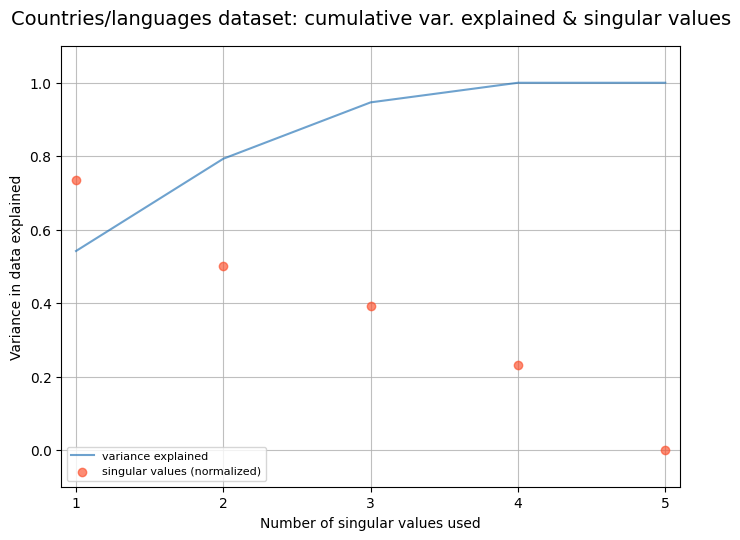

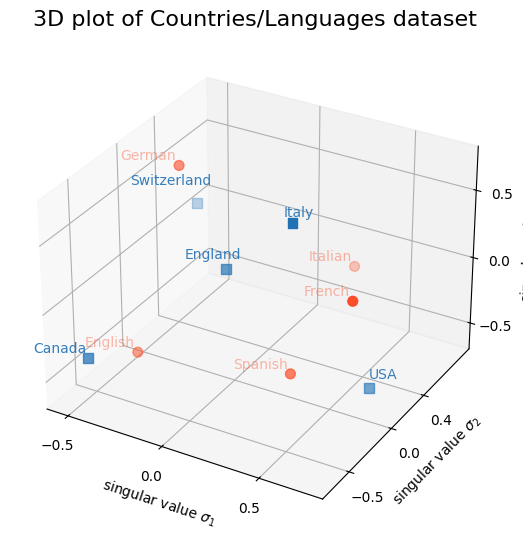

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from sklearn.preprocessing import normalize

# Load the dataset
data_path = os.path.join(os.getcwd(), 'country_language.csv')
df_countries = pd.read_csv(data_path, dtype='category')

# Display the dataset shape and first 10 rows
print("Data has {} measurements for {} variables".format(*df_countries.shape))
print("Here are the first 10 rows:\n\n{}".format(df_countries.head(10)))

# Define countries and languages
countries = ['Canada', 'USA', 'England', 'Italy', 'Switzerland']
languages = ['English', 'French', 'Spanish', 'German', 'Italian']

# Create a contingency table
F = pd.crosstab(df_countries.country, df_countries.language, margins=False)
F.index = countries
F.columns = languages
print("\nContingency table F:\n\n{}".format(F))

# Calculate the correspondence matrix P
P = F / F.sum().sum()
print("\nCorrespondence matrix P:\n\n{}".format(P))

# Calculate row and column centroids
row_centroid = P.sum(axis=1)
col_centroid = P.sum(axis=0)

print("\nRow centroid (marginal frequency distribution over countries):\n\n{}".format(row_centroid))
print("\nColumn centroid (marginal frequency distribution over languages):\n\n{}".format(col_centroid))

# Calculate the inertia matrix Lambda
Mu_ij = row_centroid.values.reshape((P.index.size, 1)) * col_centroid.values.reshape((1, P.columns.size))
Lambda = (P - Mu_ij) / np.sqrt(Mu_ij)
print("\nInertia matrix Lambda:\n\n{}".format(Lambda))

# Perform Singular Value Decomposition on Lambda
U_lambda, S_lambda, Vt_lambda = np.linalg.svd(Lambda)
num_sv_lambda = np.arange(1, S_lambda.size + 1)
cum_var_explained_lambda = [np.sum(np.square(S_lambda[0:n])) / np.sum(np.square(S_lambda)) for n in num_sv_lambda]

# Plot cumulative variance explained
plt.figure(figsize=(7.0, 5.5))
plt.plot(num_sv_lambda, cum_var_explained_lambda, color='#2171b5', label='variance explained', alpha=0.65, zorder=1000)
plt.scatter(num_sv_lambda, normalize(S_lambda.reshape((1, -1))), color='#fc4e2a', label='singular values (normalized)', alpha=0.65, zorder=1000)
plt.legend(loc='lower left', scatterpoints=1, fontsize=8)
plt.xticks(num_sv_lambda)
plt.xlim(0.9, 5.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('Number of singular values used')
plt.ylabel('Variance in data explained')
plt.title('Countries/languages dataset: cumulative var. explained & singular values', fontsize=14, y=1.03)
plt.grid(alpha=0.8, zorder=1)
plt.tight_layout()
plt.show()

# Extract coordinates for countries and languages in 3D
country_x = U_lambda[:, 0]
country_y = U_lambda[:, 1]
country_z = U_lambda[:, 2]
lang_x = Vt_lambda[0, :]
lang_y = Vt_lambda[1, :]
lang_z = Vt_lambda[2, :]

# Visualize the relation between countries and languages in 3D
fig = plt.figure(figsize=(7.5, 5.5))
ax = fig.add_subplot(111, projection='3d')

# Plot countries
ax.scatter(country_x, country_y, country_z, marker='s', s=50, c='#2171b5')
cntry_labels = []
for i, (x, y, z) in enumerate(zip(country_x, country_y, country_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    label = plt.annotate(Lambda.index[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#2171b5', alpha=0.9)
    cntry_labels.append(label)

# Plot languages
ax.scatter(lang_x, lang_y, lang_z, marker='o', s=50, c='#fc4e2a')
lang_labels = []
for i, (x, y, z) in enumerate(zip(lang_x, lang_y, lang_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    label = plt.annotate(Lambda.columns[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#fc4e2a', alpha=0.4)
    lang_labels.append(label)

# Function to update label positions
def update_position(e):
    for i, (x, y, z) in enumerate(zip(country_x, country_y, country_z)):
        x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
        cntry_labels[i].xy = x2, y2
    for i, (x, y, z) in enumerate(zip(lang_x, lang_y, lang_z)):
        x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
        lang_labels[i].xy = x2, y2
fig.canvas.mpl_connect('button_release_event', update_position)

# Set labels and title
ax.set_xlabel('singular value $\sigma_{1}$')
ax.set_xticks([-0.5, 0.0, 0.5])
ax.set_ylabel('singular value $\sigma_{2}$')
ax.set_yticks([-0.5, 0.0, 0.4])
ax.set_zlabel('singular value $\sigma_{3}$')
ax.set_zticks([-0.5, 0.0, 0.5])
ax.set_title('3D plot of Countries/Languages dataset', fontsize=16, y=1.1)
plt.tight_layout()
plt.show()


Contingency table F:
 [[424  87  88 107 294]
 [407  81 106 100 306]
 [400 100 108 115 277]
 [411  96 100 100 293]
 [391 103  97 109 300]]

Correspondence matrix P:
 [[0.0848 0.0174 0.0176 0.0214 0.0588]
 [0.0814 0.0162 0.0212 0.02   0.0612]
 [0.08   0.02   0.0216 0.023  0.0554]
 [0.0822 0.0192 0.02   0.02   0.0586]
 [0.0782 0.0206 0.0194 0.0218 0.06  ]]

Inertia matrix Lambda:
 [[ 1.22033919e-02 -9.36529655e-03 -1.67044328e-02  1.09784929e-03
   2.86155162e-17]
 [ 2.80537745e-04 -1.81452621e-02  8.77690538e-03 -8.50833202e-03
   9.89743319e-03]
 [-4.62887280e-03  9.65796207e-03  1.16081652e-02  1.20763422e-02
  -1.40213637e-02]
 [ 3.08591520e-03  3.80465172e-03  2.83125980e-04 -8.50833202e-03
  -8.24786099e-04]
 [-1.09409721e-02  1.40479448e-02 -3.96376372e-03  3.84247252e-03
   4.94871659e-03]]


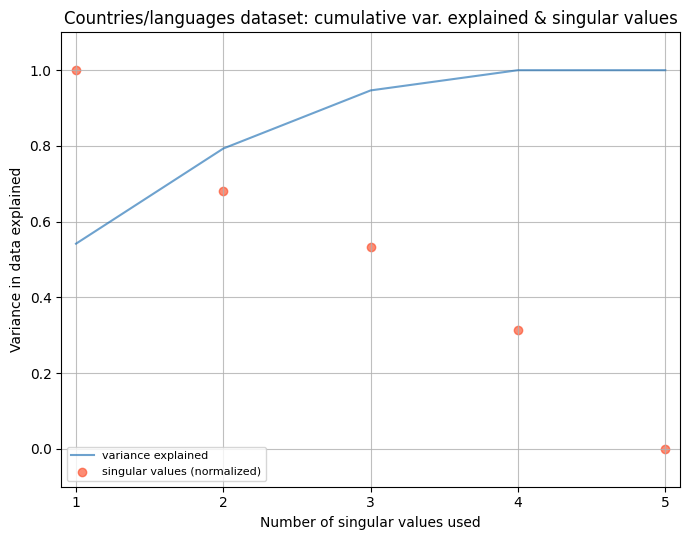

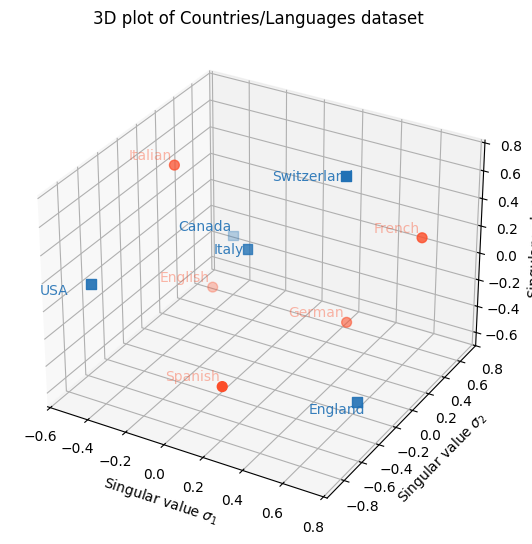

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d

# 设定随机种子以确保结果可复现
np.random.seed(42)

# 定义国家和语言
countries = np.array(['Canada', 'USA', 'England', 'Italy', 'Switzerland'])
languages = np.array(['English', 'French', 'Spanish', 'German', 'Italian'])

# 生成模拟数据
num_respondents_per_country = 1000
num_countries = len(countries)
num_languages = len(languages)
total_respondents = num_countries * num_respondents_per_country

# 为每个国家分配一个编号
country_indices = np.tile(np.arange(num_countries), num_respondents_per_country)

# 随机选择语言，模拟数据分布
language_indices = np.random.choice(num_languages, size=total_respondents, p=[0.4, 0.1, 0.1, 0.1, 0.3])

# 创建一个二维的联列表（contingency table）
F = np.zeros((num_countries, num_languages), dtype=int)
for country, lang in zip(country_indices, language_indices):
    F[country, lang] += 1

# 打印联列表
print("Contingency table F:\n", F)

# 计算对应矩阵P
P = F / F.sum()
print("\nCorrespondence matrix P:\n", P)

# 计算行和列的中心点（质心）
row_centroid = P.sum(axis=1).reshape(-1, 1)
col_centroid = P.sum(axis=0).reshape(1, -1)

# 计算惯性矩阵Lambda
Mu_ij = row_centroid * col_centroid
Lambda = (P - Mu_ij) / np.sqrt(Mu_ij)
print("\nInertia matrix Lambda:\n", Lambda)

# 对惯性矩阵Lambda进行奇异值分解（SVD）
U_lambda, S_lambda, Vt_lambda = np.linalg.svd(Lambda)
num_sv_lambda = np.arange(1, S_lambda.size + 1)
cum_var_explained_lambda = np.cumsum(S_lambda**2) / np.sum(S_lambda**2)

# 绘制累积方差解释图
plt.figure(figsize=(7.0, 5.5))
plt.plot(num_sv_lambda, cum_var_explained_lambda, color='#2171b5', label='variance explained', alpha=0.65)
plt.scatter(num_sv_lambda, S_lambda / S_lambda.max(), color='#fc4e2a', label='singular values (normalized)', alpha=0.65)
plt.legend(loc='lower left', scatterpoints=1, fontsize=8)
plt.xticks(num_sv_lambda)
plt.xlim(0.9, 5.1)
plt.ylim(-0.1, 1.1)
plt.xlabel('Number of singular values used')
plt.ylabel('Variance in data explained')
plt.title('Countries/languages dataset: cumulative var. explained & singular values')
plt.grid(alpha=0.8)
plt.tight_layout()

# 提取国家和语言在3D空间中的坐标
country_x = U_lambda[:, 0]
country_y = U_lambda[:, 1]
country_z = U_lambda[:, 2]
lang_x = Vt_lambda[0, :]
lang_y = Vt_lambda[1, :]
lang_z = Vt_lambda[2, :]

# 在3D空间中可视化国家和语言的关系
fig = plt.figure(figsize=(7.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(country_x, country_y, country_z, marker='s', s=50, c='#2171b5')
for i, (x, y, z) in enumerate(zip(country_x, country_y, country_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    ax.annotate(countries[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#2171b5', alpha=0.9)
ax.scatter(lang_x, lang_y, lang_z, marker='o', s=50, c='#fc4e2a')
for i, (x, y, z) in enumerate(zip(lang_x, lang_y, lang_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    ax.annotate(languages[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#fc4e2a', alpha=0.4)

# 设置标签和标题
ax.set_xlabel('Singular value $\sigma_{1}$')
ax.set_ylabel('Singular value $\sigma_{2}$')
ax.set_zlabel('Singular value $\sigma_{3}$')
ax.set_title('3D plot of Countries/Languages dataset')
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d

# 设定随机种子以确保结果可复现
np.random.seed(42)

# 定义国家和语言
countries = np.array(['Canada', 'USA', 'England', 'Italy', 'Switzerland'])
languages = np.array(['English', 'French', 'Spanish', 'German', 'Italian'])

# 生成模拟数据
num_respondents_per_country = 1000
num_countries = len(countries)
num_languages = len(languages)
total_respondents = num_countries * num_respondents_per_country

# 为每个国家分配一个编号
country_indices = np.tile(np.arange(num_countries), num_respondents_per_country)
language_indices = np.random.choice(num_languages, size=total_respondents, p=[0.4, 0.1, 0.1, 0.1, 0.3])

# 创建一个二维的联列表（contingency table）
F = np.zeros((num_countries, num_languages), dtype=int)
for country, lang in zip(country_indices, language_indices):
    F[country, lang] += 1

print(F)


[[424  87  88 107 294]
 [407  81 106 100 306]
 [400 100 108 115 277]
 [411  96 100 100 293]
 [391 103  97 109 300]]


# 分类数据的SVD方法
根据https://notebook.community/buruzaemon/svd/01_SVD_visualizing_data example2的例子改写，自己生成测试数据，并只用numpy，不用pandas

In [92]:
# 生成country_language.csv，这个文件里面包括2列，分别是国家名称和使用的语言，每个国家生成1200个样本，具体各个国家使用语言的数量，按照下表比例生成
# 
# 	Canada	USA	England	Italy	Switzerland
# English	59	79	94	9	25
# French	33	3	1	3	30
# Spanish	2	10	3	5	4
# German	2	3	1	1	34
# Italian	4	5	1	82	7

import pandas as pd
import numpy as np

# 定义国家和对应的语言比例
countries = ['USA', 'England', 'Italy', 'Switzerland']
languages = ['English', 'French', 'Spanish', 'German', 'Italian']
proportions = {
    'USA': [79, 3, 10, 3, 5],
    'England': [94, 1, 3, 1, 1],
    'Italy': [9, 3, 5, 1, 82],
    'Switzerland': [25, 30, 4, 34, 7]
}

# 初始化一个空的 DataFrame
df = pd.DataFrame(columns=['Country', 'Language'])

# 为每个国家生成样本
for country in countries:
    print(np.array(proportions[country])/2)
    # 根据比例生成语言样本
    language_samples = np.random.choice(languages, size=1200, p=np.array(proportions[country])/100)
    # 创建 DataFrame 并追加到总 DataFrame 中
    country_df = pd.DataFrame({'Country': country, 'Language': language_samples})
    df = pd.concat([df, country_df], ignore_index=True)

# 将 DataFrame 保存为 CSV 文件
df.to_csv('country_language.csv', index=False)

print("CSV 文件已生成并保存为 'country_language.csv'")


[39.5  1.5  5.   1.5  2.5]
[47.   0.5  1.5  0.5  0.5]
[ 4.5  1.5  2.5  0.5 41. ]
[12.5 15.   2.  17.   3.5]
CSV 文件已生成并保存为 'country_language.csv'


[[0.51145833]
 [0.09291667]
 [0.059375  ]
 [0.10291667]
 [0.23333333]]
[[0.25 0.25 0.25 0.25]]
[[0.12786458 0.12786458 0.12786458 0.12786458]
 [0.02322917 0.02322917 0.02322917 0.02322917]
 [0.01484375 0.01484375 0.01484375 0.01484375]
 [0.02572917 0.02572917 0.02572917 0.02572917]
 [0.05833333 0.05833333 0.05833333 0.05833333]]
inertia Lambda:

[[ 0.18250498  0.29203709 -0.29116316 -0.1833789 ]
 [-0.10320219 -0.1373751  -0.10730294  0.34788022]
 [ 0.10217034 -0.04317659 -0.0141072  -0.04488655]
 [-0.09935903 -0.14221979 -0.14741503  0.38899384]
 [-0.19063061 -0.2294468   0.60380736 -0.18372996]]


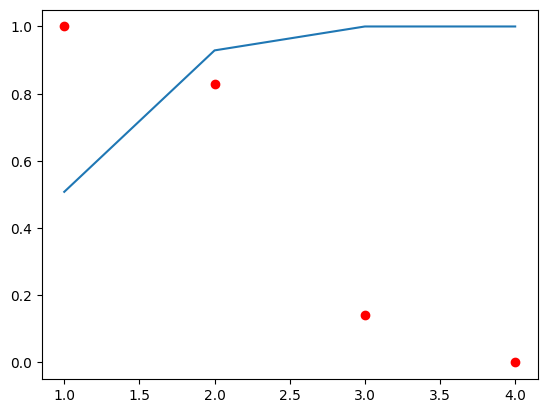

(5, 5)
(4,)
(4, 4)


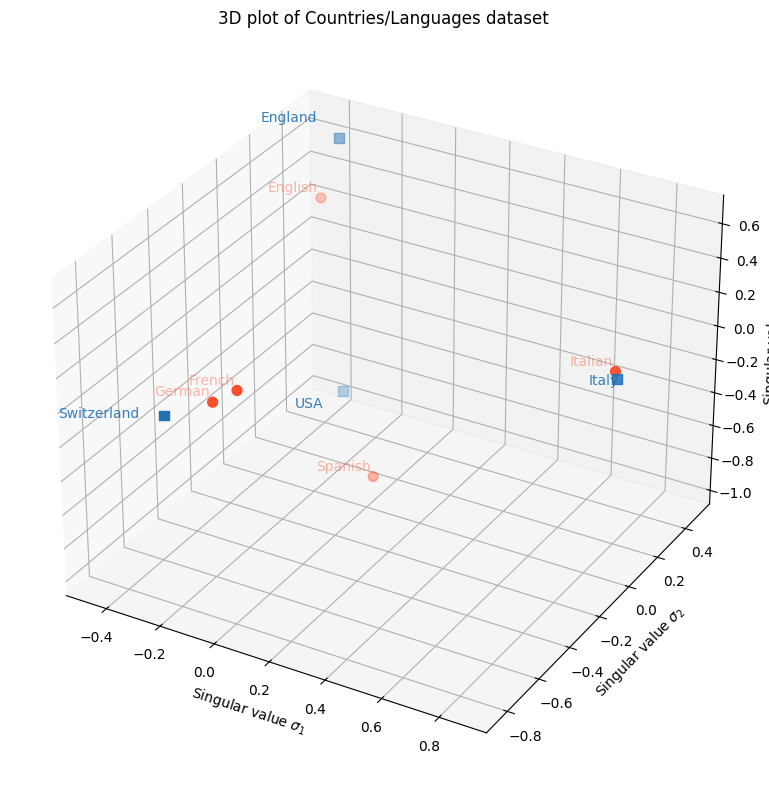

In [22]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D, proj3d

countries = np.array(['USA', 'England', 'Italy', 'Switzerland'])
languages = np.array(['English', 'French', 'Spanish', 'German', 'Italian'])

data = np.genfromtxt('country_language.csv', delimiter=',', dtype=None, encoding=None, skip_header=1)

F = np.zeros((len(languages), len(countries)), dtype=int)

for country in countries:
    country_index = np.where(countries==country)[0][0]
    
    inds, = np.where(data[:,0]==country)
    langs, counts = np.unique(data[inds, 1], return_counts=True)
    for i, lang in enumerate(langs):
        lang_index = np.where(languages==lang)[0][0]
        F[lang_index, country_index] = counts[i]


P = F / F.sum()

# 计算行和列的中心点（质心）
row_centroid = P.sum(axis=1).reshape(-1, 1)
col_centroid = P.sum(axis=0).reshape(1, -1)

# 计算惯性矩阵Lambda
Mu_ij = row_centroid * col_centroid
print(row_centroid)
print(col_centroid)
print(Mu_ij)

Lambda = (P - Mu_ij) / np.sqrt(Mu_ij)

print('inertia Lambda:\n\n{}'.format(Lambda))


# 对惯性矩阵Lambda进行奇异值分解（SVD）
U_lambda, S_lambda, Vt_lambda = np.linalg.svd(Lambda)
num_sv_lambda = np.arange(1, S_lambda.size + 1)
# cum_var_explained_lambda = np.cumsum(S_lambda**2) / np.sum(S_lambda**2)
cum_var_explained_lambda = np.cumsum(S_lambda) / np.sum(S_lambda)

# 绘制累积方差解释图
plt.plot(num_sv_lambda, cum_var_explained_lambda)
plt.scatter(num_sv_lambda, S_lambda / S_lambda.max(), color='red')
plt.show()

print(U_lambda.shape)
print(S_lambda.shape)
print(Vt_lambda.shape)

# 提取国家和语言在3D空间中的坐标
lang_x = U_lambda[:, 0]
lang_y = U_lambda[:, 1]
lang_z = U_lambda[:, 2]
country_x = Vt_lambda[0, :]
country_y = Vt_lambda[1, :]
country_z = Vt_lambda[2, :]


# 在3D空间中可视化国家和语言的关系
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(country_x, country_y, country_z, marker='s', s=50, c='#2171b5')
for i, (x, y, z) in enumerate(zip(country_x, country_y, country_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    ax.annotate(countries[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#2171b5', alpha=0.9)
ax.scatter(lang_x, lang_y, lang_z, marker='o', s=50, c='#fc4e2a')
for i, (x, y, z) in enumerate(zip(lang_x, lang_y, lang_z)):
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    ax.annotate(languages[i], xy=(x2, y2), xytext=(-2, 2), textcoords='offset points', ha='right', va='bottom', color='#fc4e2a', alpha=0.4)

# # 设置标签和标题
ax.set_xlabel('Singular value $\sigma_{1}$')
ax.set_ylabel('Singular value $\sigma_{2}$')
ax.set_zlabel('Singular value $\sigma_{3}$')
ax.set_title('3D plot of Countries/Languages dataset')
plt.tight_layout()
plt.show()


# energy_data

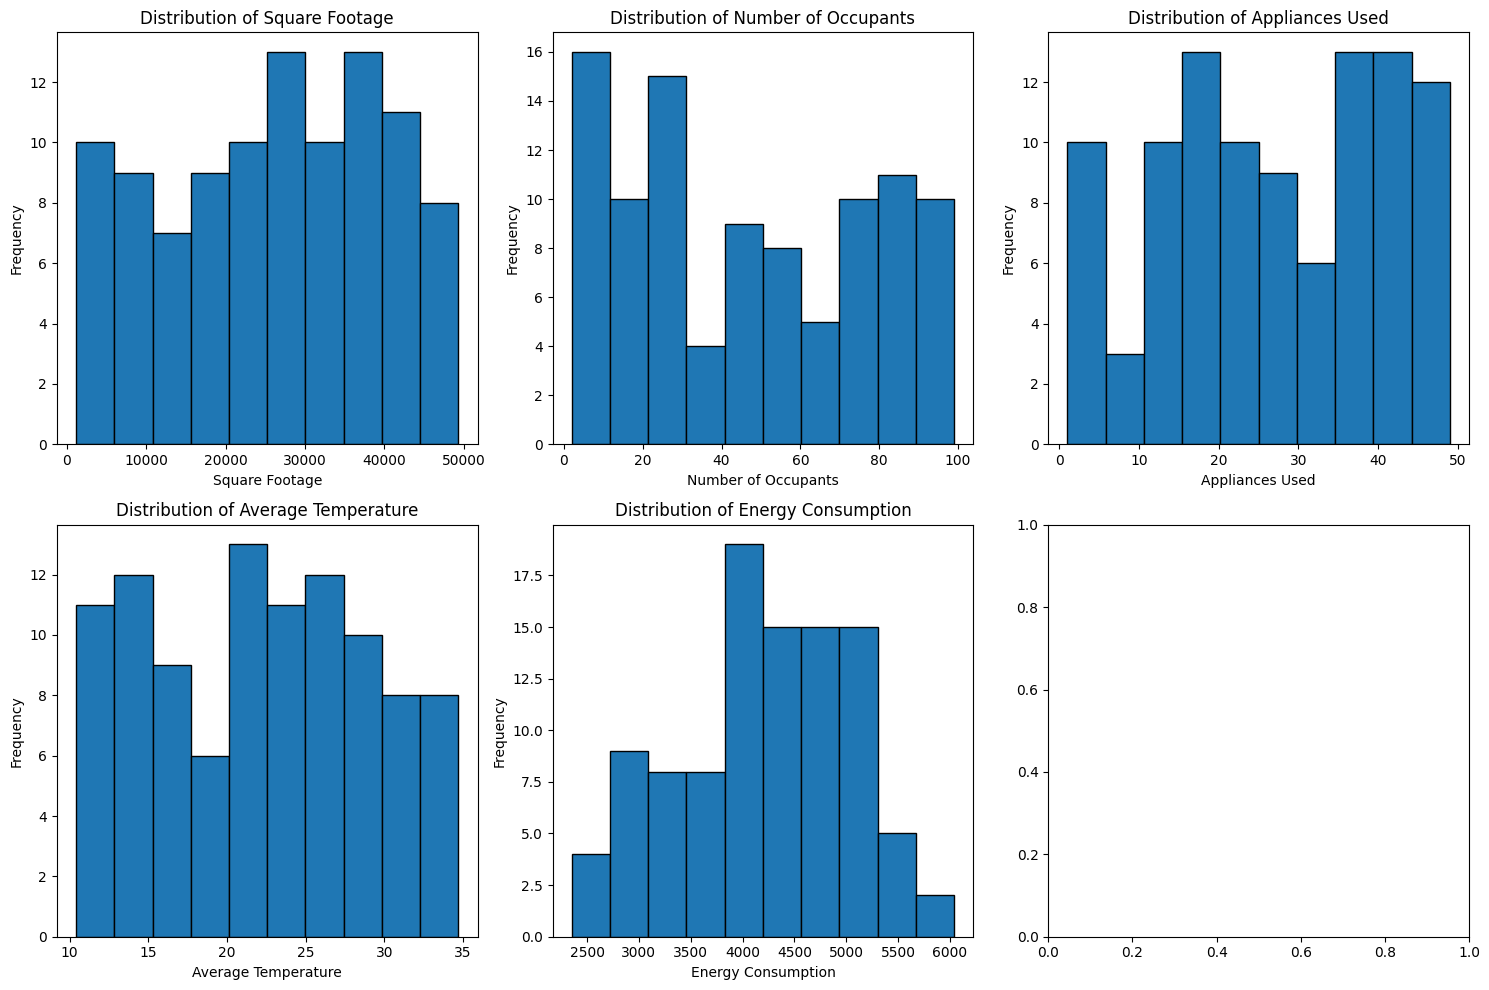

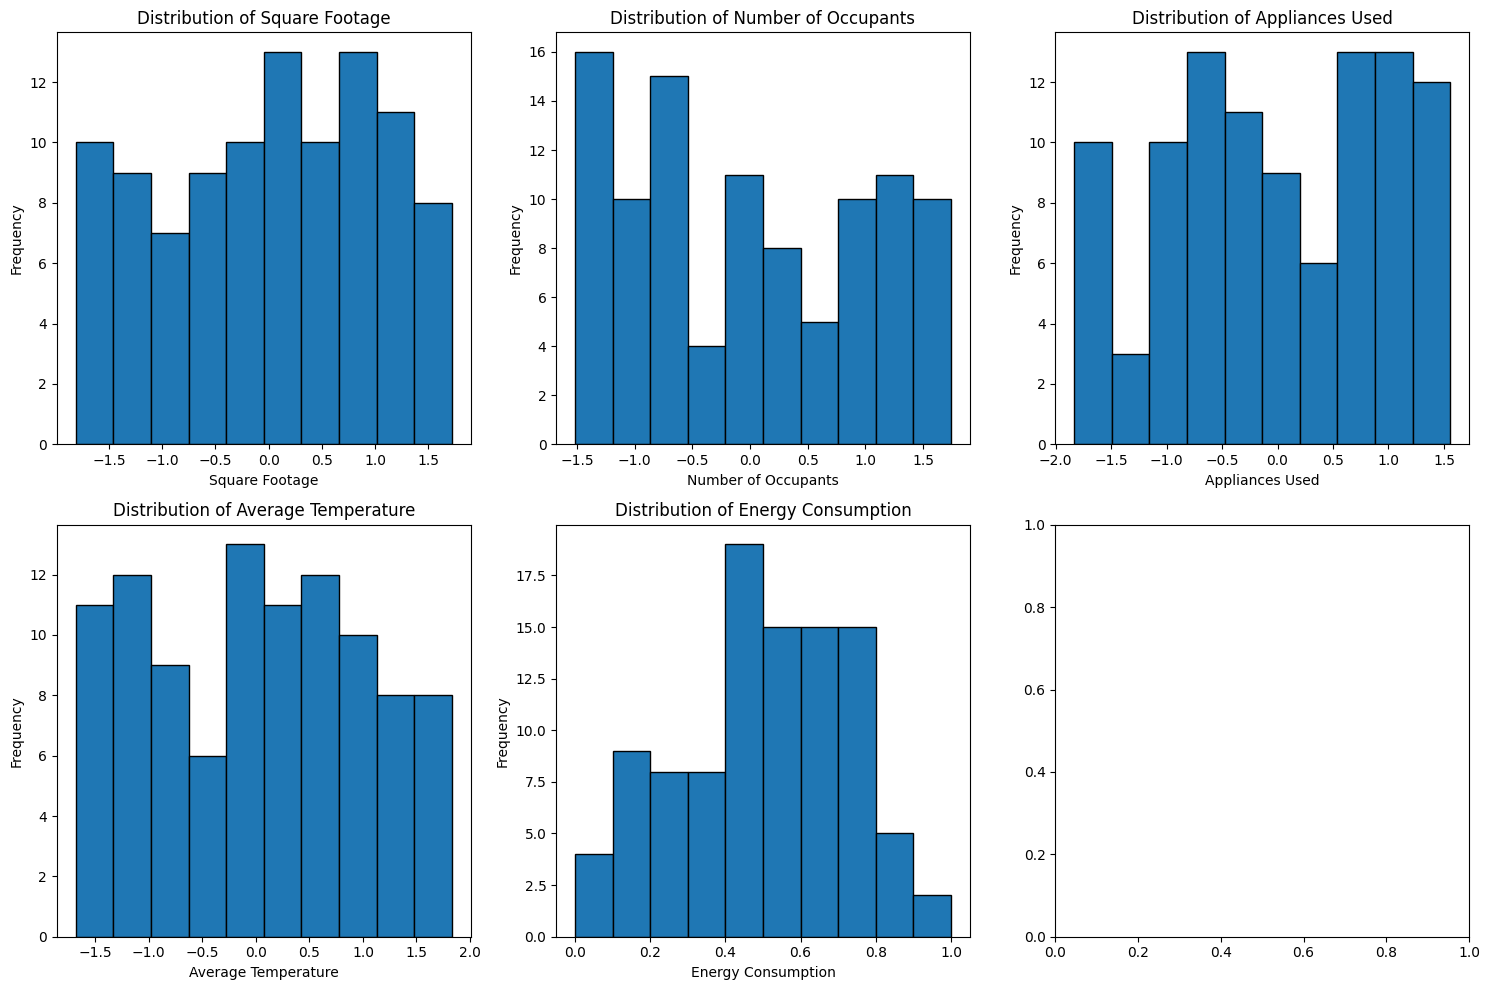

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler

def hists(df):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

    for row in range(2):
        for col in range(3):
            i = row * 3 + col
            if i >= 5: break
            
            dfColName = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption'][i]

            axes[row][col].hist(df[dfColName], bins=10, edgecolor='black')
            axes[row][col].set_title(f'Distribution of {dfColName}')
            axes[row][col].set_xlabel(dfColName)
            axes[row][col].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


df = pd.read_csv('energy_data.csv')
hists(df)



missing_val_cols = df.columns[df.isnull().any()].tolist()
imputer = SimpleImputer(strategy='mean')
df[missing_val_cols] = imputer.fit_transform(df[missing_val_cols])

ohEnc = OneHotEncoder()
enc_df = pd.DataFrame(ohEnc.fit_transform(df[['Building Type']]).toarray())
enc_df.columns = ohEnc.get_feature_names_out(['Building Type']).tolist()

df = df.join(enc_df)
df.drop('Building Type', axis=1, inplace=True)


encoder_label = LabelEncoder()
df['Day of Week'] = encoder_label.fit_transform(df['Day of Week'])

scaler_minmax = MinMaxScaler()
df['Energy Consumption'] = scaler_minmax.fit_transform(df[['Energy Consumption']])

scaler_standard = StandardScaler()
df[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']] = scaler_standard.fit_transform(df[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']])

hists(df)




## 修改不用sklearn和panda只用numpy

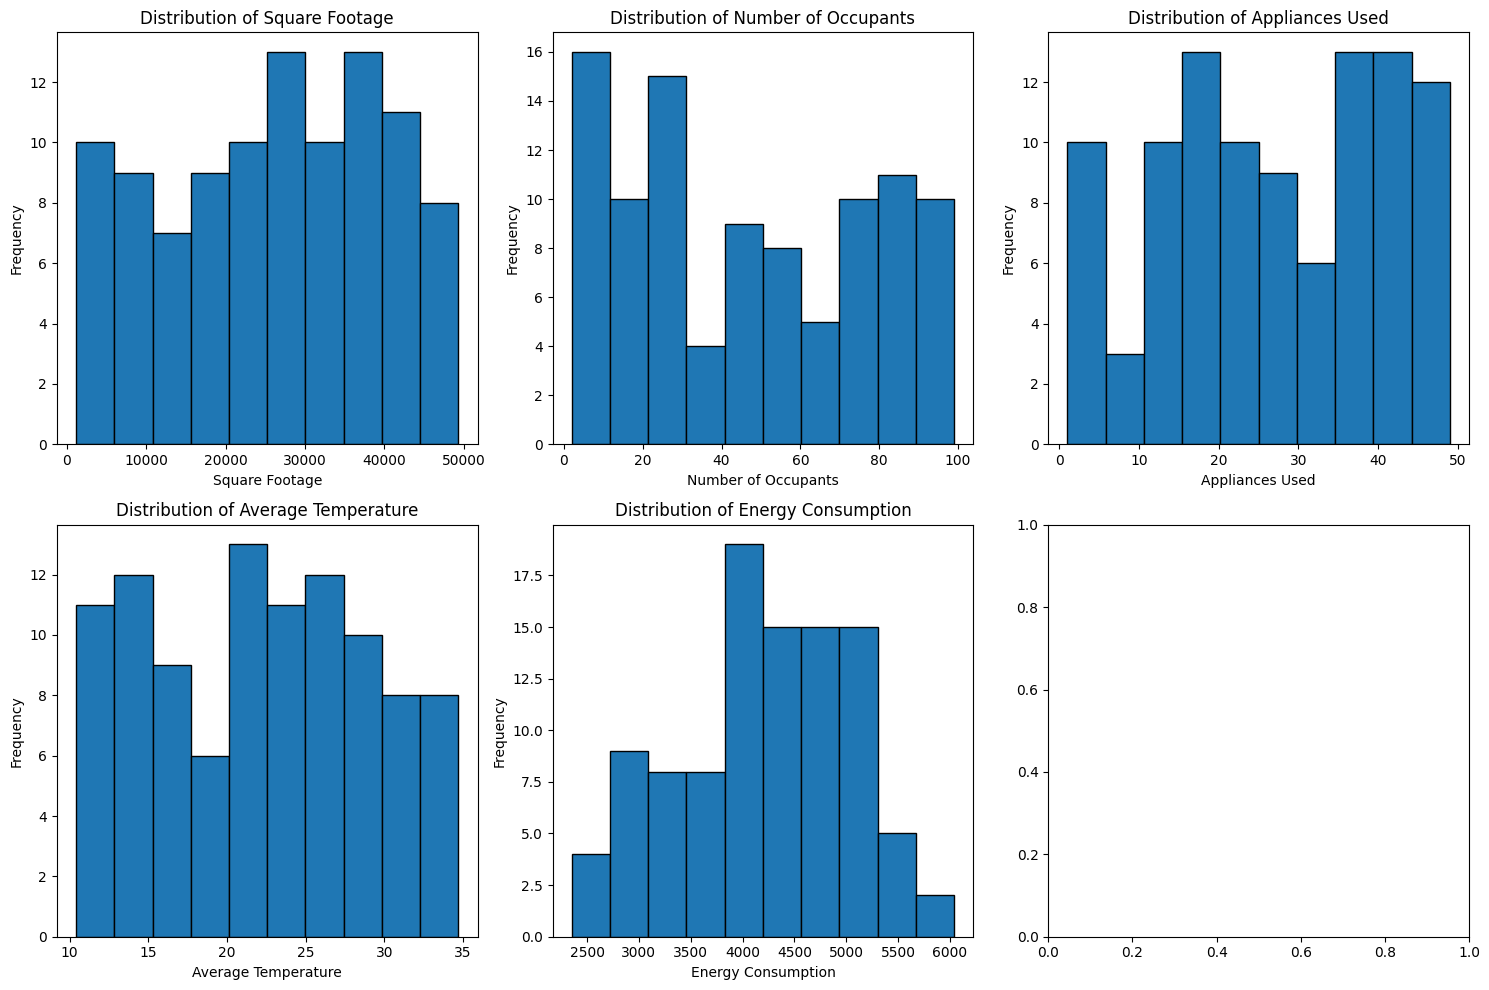

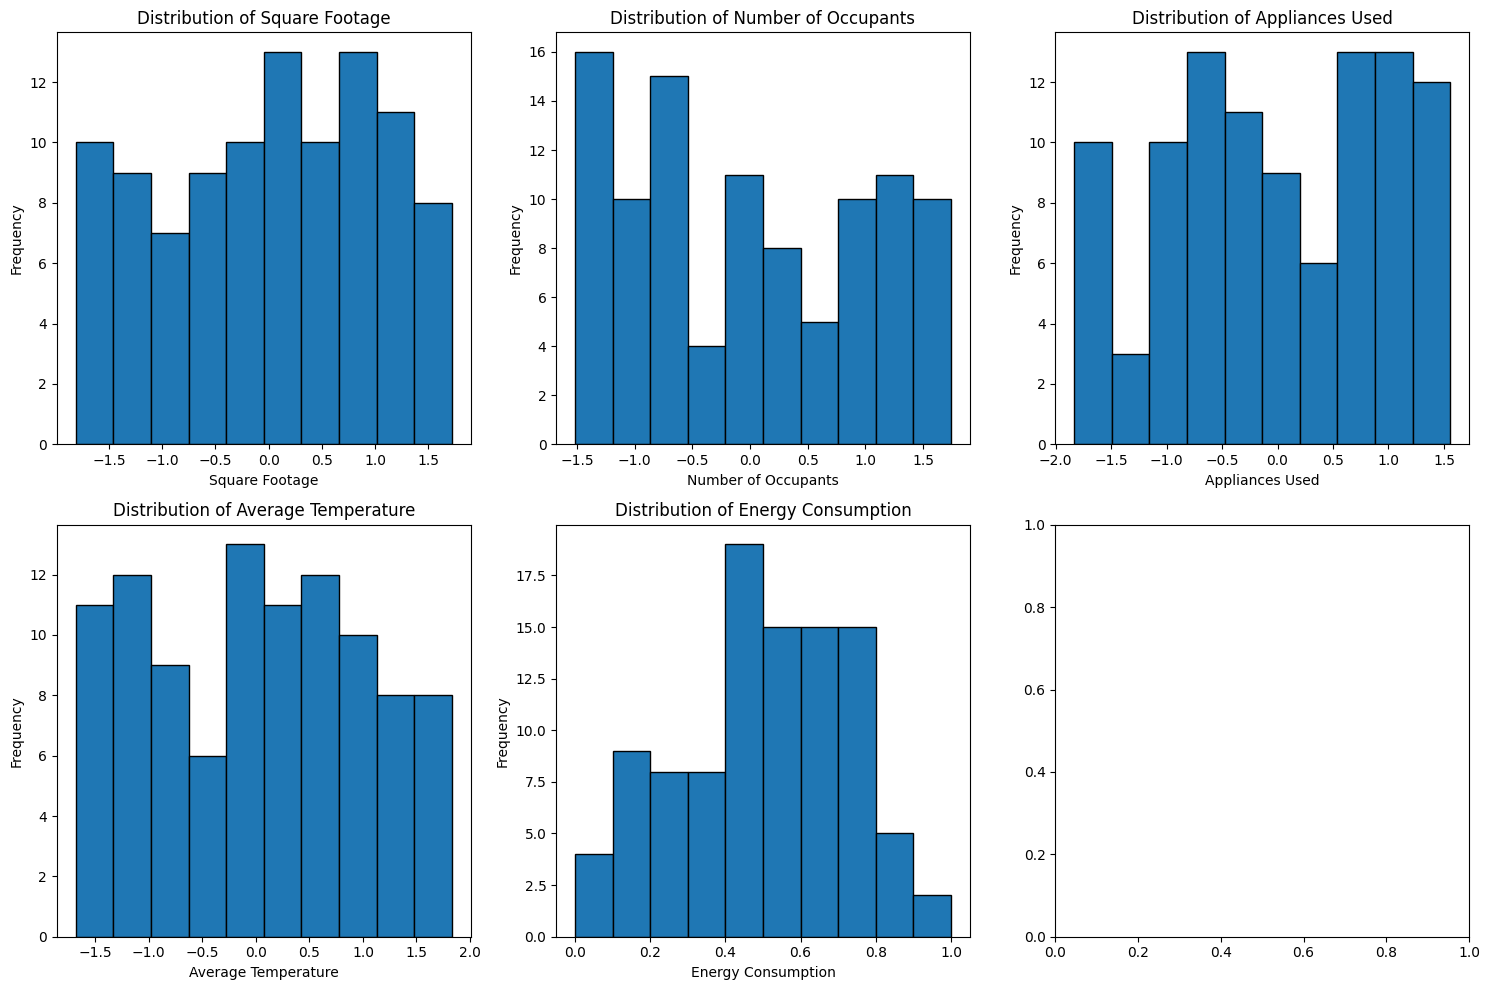

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler

def hists(df):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

    for row in range(2):
        for col in range(3):
            i = row * 3 + col
            if i >= 5: break
            
            dfColName = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption'][i]

            axes[row][col].hist(df[dfColName], bins=10, edgecolor='black')
            axes[row][col].set_title(f'Distribution of {dfColName}')
            axes[row][col].set_xlabel(dfColName)
            axes[row][col].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


df = pd.read_csv('energy_data.csv')
hists(df)



missing_val_cols = df.columns[df.isnull().any()].tolist()
imputer = SimpleImputer(strategy='mean')
df[missing_val_cols] = imputer.fit_transform(df[missing_val_cols])

ohEnc = OneHotEncoder()
enc_df = pd.DataFrame(ohEnc.fit_transform(df[['Building Type']]).toarray())
enc_df.columns = ohEnc.get_feature_names_out(['Building Type']).tolist()

df = df.join(enc_df)
df.drop('Building Type', axis=1, inplace=True)


encoder_label = LabelEncoder()
df['Day of Week'] = encoder_label.fit_transform(df['Day of Week'])

scaler_minmax = MinMaxScaler()
df['Energy Consumption'] = scaler_minmax.fit_transform(df[['Energy Consumption']])

scaler_standard = StandardScaler()
df[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']] = scaler_standard.fit_transform(df[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']])

hists(df)